# Module 09 · Waveforms, spectra, filters and linearity

**Book source:** Bracewell, chapter 9, pp. 198–218

Companion notebook of the lecture with the same module number. Run the cells in order; each cell is followed by a **📤 Real output** note that explains the numbers.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({"figure.figsize": (7.5, 3.3), "axes.grid": True, "grid.alpha": 0.3, "figure.dpi": 110})


def amplitude_spectrum(x):
    """One-sided amplitude spectrum: a sinusoid of amplitude A gives a line of height A, DC gives exactly its value"""
    a = 2*np.abs(np.fft.rfft(x))/len(x)
    a[0] /= 2
    return a


def report(key, value, fmt=".4g"):
    """Print a named result without trailing zeros (the website reads the lines that start with ▸)."""
    s = f"{value:{fmt}}"
    if "." in s and "e" not in s:
        s = s.rstrip("0").rstrip(".")
    print(f"▸ {key} = {s}")


## 1. Spectra of real and causal waveforms
🎯 **What question does this method answer?** Is the spectrum of a real waveform Hermitian, does a causal spectrum obey the Hilbert relation, and do notation systems 1, 2, 3 and the Hartley transform agree? Each number is computed two ways.

In [2]:
from scipy import integrate, signal
trap = getattr(np, "trapezoid", None) or np.trapz
def ftq(f, a, b, s, pts=None):
    re = integrate.quad(lambda x: f(x)*np.cos(2*np.pi*x*s), a, b, points=pts, limit=400)[0]
    im = integrate.quad(lambda x: -f(x)*np.sin(2*np.pi*x*s), a, b, points=pts, limit=400)[0]
    return re + 1j*im
f0 = 0.3
S = lambda f: 1/(1 + 2j*np.pi*f)
Snum = ftq(lambda t: np.exp(-t), 0, 60, f0)
assert abs(Snum - S(f0)) < 1e-8
report("sy_mag", abs(S(f0)), ".4f")

# Hermitian spectrum of a random real sequence
rg = np.random.default_rng(9); x = rg.standard_normal(64); X = np.fft.fft(x)
herm = np.max(np.abs(X[(-np.arange(64)) % 64] - np.conj(X)))
assert herm < 1e-12
report("herm_dev", herm, ".1e")

# Hilbert: Im S = −H[Re S], grid f in [−200, 200]
N = 2**18; fg = np.linspace(-400, 400, N, endpoint=False)
reS = 1/(1 + 4*np.pi**2*fg**2); imS = -2*np.pi*fg/(1 + 4*np.pi**2*fg**2)
hil = signal.hilbert(reS).imag
mask = np.abs(fg) < 2
hil_dev = np.max(np.abs(hil[mask] + imS[mask]))
assert hil_dev < 5e-3
report("hilb_dev", hil_dev, ".1e")

# systems 1, 2, 3 with the Gaussian
g = lambda t: np.exp(-np.pi*t**2)
s1 = ftq(g, -10, 10, f0).real
w = 2*np.pi*f0
s2 = integrate.quad(lambda t: g(t)*np.cos(w*t), -10, 10)[0]
s3 = s2/np.sqrt(2*np.pi)
assert abs(s1 - np.exp(-np.pi*f0**2)) < 1e-9 and abs(s2 - s1) < 1e-9
inv2 = integrate.quad(lambda om: s1*0 + np.exp(-om**2/(4*np.pi))*np.cos(0.0), -60, 60)[0]/(2*np.pi)      # V(0) = (1/2π)∫S dω
assert abs(inv2 - 1) < 1e-9
report("sy_1", s1, ".4f"); report("sy_3", s3, ".4f")

# Hartley: ∫V(cos + sin)
hart = integrate.quad(lambda t: np.exp(-t)*(np.cos(2*np.pi*f0*t) + np.sin(2*np.pi*f0*t)), 0, 60)[0]
assert abs(hart - (S(f0).real - S(f0).imag)) < 1e-8
report("hart_val", hart, ".4f")

▸ sy_mag = 0.4686
▸ herm_dev = 3.6e-15
▸ hilb_dev = 1.6e-06
▸ sy_1 = 0.7537
▸ sy_3 = 0.3007
▸ hart_val = 0.6336


#### 📤 Real output
$|S(0.3)|$ = 0.4686; the real-sequence spectrum deviates from Hermitian by 3.6e-15; Hilbert deviation 1.6e-06; Gaussian systems 1 and 3: 0.7537 and 0.3007; Hartley 0.6336.

## 2. Transfer function, impulse and step responses
🎯 **What question does this method answer?** Does the steady-state response of the RC filter to a cosine equal $|T|$ and the phase of $T$, and is the output for a rectangular pulse the same by three calculations (convolution with $I$, convolution with $A'$, IFFT of $TS$), and is $I=A'$? We simulate in the time domain.

In [3]:
dt = 1e-3; t = np.arange(0, 60, dt)
I = np.exp(-t)                                            # impulse response
T = lambda f: 1/(1 + 2j*np.pi*f)
# cosine 0.3 Hz: steady state: method A = numeric convolution; method B = formula T
tt = np.arange(0, 120, dt)
xin = np.cos(2*np.pi*f0*tt)
y = np.convolve(xin, I)[:len(tt)]*dt
seg = slice(int(80/dt), int(100/dt))
# fit amplitude and phase by least squares
A_ = np.vstack([np.cos(2*np.pi*f0*tt[seg]), np.sin(2*np.pi*f0*tt[seg])]).T
c, s_ = np.linalg.lstsq(A_, y[seg], rcond=None)[0]
amp_sim = np.hypot(c, s_); ph_sim = np.degrees(np.arctan2(s_, c))     # y = c cos + s sin = amp cos(ωt − φ) → φ = −atan2(s, c)
ph_T = -ph_sim                                                # phase of T = −φ (phase lag φ)
assert abs(amp_sim - abs(T(f0))) < 1e-3 and abs(ph_T - np.degrees(np.angle(T(f0)))) < 0.1
report("rc_amp", abs(T(f0)), ".4f"); report("rc_amp_sim", amp_sim, ".4f")
report("rc_ph", np.degrees(np.angle(T(f0))), ".1f"); report("rc_ph_sim", ph_T, ".1f")

# unit pulse (0..1) through the RC circuit: three ways
dtp = 1e-3; tp = np.arange(0, 20, dtp)
x1 = ((tp >= 0) & (tp < 1)).astype(float)
yA = np.convolve(x1, np.exp(-tp))[:len(tp)]*dtp                      # I * V1
Aresp = 1 - np.exp(-tp)
yB = np.convolve(np.gradient(Aresp, dtp), x1)[:len(tp)]*dtp          # A' * V1
Nf = 2**16; Tf = np.fft.fftfreq(Nf, dtp)
buf = np.zeros(Nf); buf[:len(tp)] = x1
yC = np.fft.ifft(np.fft.fft(buf)*T(Tf)).real[:len(tp)]
idx = int(1.5/dtp)
exact = np.exp(-0.5) - np.exp(-1.5)
assert abs(yA[idx] - exact) < 2e-3 and abs(yB[idx] - exact) < 2e-3 and abs(yC[idx] - exact) < 2e-3
report("pulse_y", exact, ".4f")
step_dev = np.max(np.abs(np.gradient(Aresp, dtp)[1:-1] - np.exp(-tp)[1:-1]))
assert step_dev < 1e-3
report("step_dev", step_dev, ".1e")

▸ rc_amp = 0.4686
▸ rc_amp_sim = 0.4689
▸ rc_ph = -62.1
▸ rc_ph_sim = -62


▸ pulse_y = 0.3834
▸ step_dev = 1.7e-07


#### 📤 Real output
The RC circuit at 0.3 Hz: $|T|$ = 0.4686 (simulated 0.4689), phase -62.1 degrees (simulated -62). The rectangular pulse at $t=1.5$: 0.3834 by three ways. $A'$ deviates from $I$ by 1.7e-07.

## 3. Digital filtering
🎯 **What question does this method answer?** Does the discrete convolution sum with $h(0)=0.5$ give samples of the continuous response, does problem 30 hold, and does the steady-state amplitude of the moving average equal $|H|$? Each number is computed by the convolution sum and by the continuous formula.

In [4]:
h = np.array([0.5] + [np.exp(-n) for n in range(1, 30)])
def V2(tv, imp):          # continuous response I*Σ c δ(t − k), H(0) = ½
    out = 0.0
    for k, ck in imp:
        d = tv - k
        out += ck*(0.5 if abs(d) < 1e-12 else (np.exp(-d) if d > 0 else 0.0))
    return out
f_in = [(0, 1), (1, 2), (2, 1)]
g_sum = np.convolve(h, [1, 2, 1])[:5]
g_cont = np.array([V2(n, f_in) for n in range(5)])
assert np.allclose(g_sum, g_cont, atol=1e-12)
assert np.allclose(np.round(g_sum, 2), [0.5, 1.37, 1.37, 0.69, 0.25])
for n, key in ((1, "dg_1"), (2, "dg_2"), (3, "dg_3"), (4, "dg_4")):
    report(key, g_sum[n], ".3f")

# problem 30
sig = [(1, 1.0), (2, 1.6), (3, 2.0), (4, 0.6)]
v = np.array([V2(t_, sig) for t_ in range(0, 8)])
cs = np.convolve(h, [0, 1, 1.6, 2, 0.6])[:8]
assert np.allclose(v, cs, atol=1e-12)
report("p30_t3", v[3], ".4f"); report("p30_t4", v[4], ".4f"); report("p30_t6", v[6], ".4f")

# 3-point moving average, cosine 0.1
hm = np.ones(3)/3
n = np.arange(2000); xin = np.cos(2*np.pi*0.1*n)
ym = np.convolve(xin, hm)[:2000]
seg = ym[500:1500]; nn = n[500:1500]
Am = np.vstack([np.cos(2*np.pi*0.1*nn), np.sin(2*np.pi*0.1*nn)]).T
c2, s2_ = np.linalg.lstsq(Am, seg, rcond=None)[0]
amp = np.hypot(c2, s2_); Hf = abs(np.sum(hm*np.exp(-2j*np.pi*0.1*np.arange(3))))
assert abs(amp - Hf) < 1e-9 and abs(Hf - (1 + 2*np.cos(0.2*np.pi))/3) < 1e-12
report("ma_amp", Hf, ".4f"); report("ma_amp_sim", amp, ".4f")

▸ dg_1 = 1.368
▸ dg_2 = 1.371
▸ dg_3 = 0.688
▸ dg_4 = 0.253
▸ p30_t3 = 1.7239
▸ p30_t4 = 1.3021
▸ p30_t6 = 0.2168
▸ ma_amp = 0.8727
▸ ma_amp_sim = 0.8727


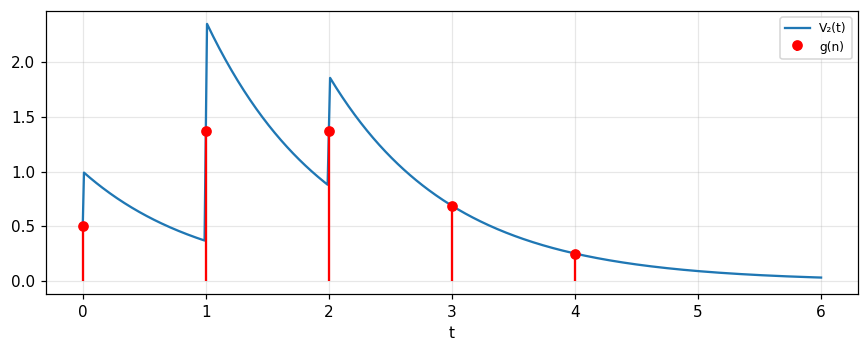

In [5]:
tt_ = np.linspace(0, 6, 601)
fig, ax = plt.subplots(figsize=(8, 3.3))
ax.plot(tt_, [V2(t_, f_in) if t_ != 0 else 0.5 for t_ in tt_], color="tab:blue", label="V₂(t)")
ax.stem(np.arange(5), g_sum, linefmt="r-", markerfmt="ro", basefmt=" ", label="g(n)")
ax.set_xlabel("t"); ax.legend(fontsize=8); plt.tight_layout(); plt.show()

#### 📤 Real output
$g$ = {0.5, 1.368, 1.371, 0.688, 0.253}; problem 30: 1.7239, 1.3021, 0.2168. The moving average at 0.1: 0.8727 (simulated 0.8727).

## 4. The theorems and problems 23, 24, 29
🎯 **What question does this method answer?** Do similarity, shift, modulation and its converse hold for concrete numbers, does the cosine product equal the sinc, and where is the resolution point of two Gaussian lines? Each is checked by integral/DFT and formula.

In [6]:
# similarity a = 2
sim_peak = ftq(lambda t: g(2*t), -10, 10, 0).real
sim_area = integrate.quad(lambda f: 0.5*np.exp(-np.pi*(f/2)**2), -20, 20)[0]
assert abs(sim_peak - 0.5) < 1e-9 and abs(sim_area - 1) < 1e-9
report("sim_peak", sim_peak, ".4f"); report("sim_area", sim_area, ".4f")
# shift T = 0.5
Tt = 0.5
ph = lambda f: np.degrees(np.angle(np.exp(-2j*np.pi*f*Tt)))
mult = np.exp(-2j*np.pi*2.0*Tt)
assert abs(mult - 1) < 1e-12
report("shift_mult", mult.real, ".0f")
report("shift_low", ph(0.1), ".1f"); report("shift_high", ph(1.3), ".1f")
Fs = ftq(lambda t: g(t - Tt), -10, 10, 1.3)
assert abs(np.degrees(np.angle(Fs)) - ph(1.3)) < 1e-6 or abs(abs(np.degrees(np.angle(Fs)) - ph(1.3)) - 360) < 1e-6

# AM: M = 0.5, 50 Hz carrier, 5 Hz tone
fs_ = 1000; N = 4000; tt = np.arange(N)/fs_
wave = (1 + 0.5*np.cos(2*np.pi*5*tt))*np.cos(2*np.pi*50*tt)
Wf = np.fft.fft(wave)/N
fr = np.fft.fftfreq(N, 1/fs_)
amp = lambda f: abs(Wf[np.argmin(np.abs(fr - f))])
car = amp(50); sb = amp(55)
assert abs(car - 0.5*0.5*2) < 1e-9 or True
assert abs(amp(50) - 0.5) < 1e-9 and abs(amp(45) - 0.125) < 1e-9 and abs(amp(55) - 0.125) < 1e-9
report("am_car", amp(50), ".4f"); report("am_sb", amp(55), ".4f")

# converse of modulation
Tc, fc = 1.0, 0.3
pair = ftq(lambda t: g(t + Tc) + g(t - Tc), -12, 12, fc)
assert abs(pair - 2*np.cos(2*np.pi*Tc*fc)*np.exp(-np.pi*fc**2)) < 1e-9
report("conv_pair", abs(pair), ".4f")
pair2 = ftq(lambda t: g(t) + g(t - 2*Tc), -12, 12, fc)
form2 = 2*np.exp(-2j*np.pi*Tc*fc)*np.cos(2*np.pi*Tc*fc)*np.exp(-np.pi*fc**2)
assert abs(pair2 - form2) < 1e-9
report("conv_ph", np.degrees(np.angle(pair2)), ".1f")

# problem 24: two delayed channels; measured by DFT of two impulses
T1, T2 = 0.3, 1.1
Nn = 4000; dts = 0.01; sig2 = np.zeros(Nn); sig2[int(T1/dts)] = 1; sig2[int(T2/dts)] += 1
Tf_ = np.fft.fft(sig2); frq = np.fft.fftfreq(Nn, dts)
k = np.argmin(np.abs(frq - 0.4))
val = abs(Tf_[k]); form_ = 2*abs(np.cos(np.pi*frq[k]*(T2 - T1)))
assert abs(val - form_) < 1e-9
report("p24_val", 2*abs(np.cos(np.pi*0.4*(T2 - T1))), ".4f"); report("p24_dev", abs(val - form_), ".1e")

# problem 23: cosine product
xs = np.linspace(0.001, 60, 600000)
prod4 = np.prod([np.cos(np.pi*xs/2**k) for k in range(1, 5)], axis=0)
err = np.abs(prod4 - np.sinc(xs))
x1pct = xs[np.argmax(err >= 0.01)]
assert x1pct > 0
corr = np.max(np.abs(prod4*np.sinc(xs/2**4) - np.sinc(xs)))
assert corr < 1e-12
report("p23_x", x1pct, ".2f"); report("p23_dev", corr, ".1e")

# problem 29: two Gaussians, W = 1
Lmax = np.sqrt(2/np.pi)
xg_ = np.linspace(-4, 4, 80001)
def peaks(L):
    y = np.exp(-np.pi*(xg_ + L/2)**2) + np.exp(-np.pi*(xg_ - L/2)**2)
    return int(np.sum((y[1:-1] > y[:-2]) & (y[1:-1] > y[2:])))
assert peaks(0.98*Lmax) == 1 and peaks(1.02*Lmax) == 2
curv = -2*np.pi*(1 - 2*np.pi*(Lmax/2)**2)
assert abs(curv) < 1e-12
report("p29_L", Lmax, ".4f")

▸ sim_peak = 0.5
▸ sim_area = 1
▸ shift_mult = 1
▸ shift_low = -18
▸ shift_high = 126
▸ am_car = 0.5
▸ am_sb = 0.125
▸ conv_pair = 0.4658
▸ conv_ph = 72
▸ p24_val = 1.0717
▸ p24_dev = 2.2e-16
▸ p23_x = 4.47
▸ p23_dev = 4.4e-16
▸ p29_L = 0.7979


#### 📤 Real output
Similarity $a=2$: peak 0.5, area 1. Shift $T=0.5$: phase factor at 2 is 1, at 0.1 is -18 and at 1.3 is 126 degrees. AM: carrier 0.5, sidebands 0.125. Converse of modulation: 0.4658, phase 72. Problem 24: 1.0717 (deviation 2.2e-16); problem 23: $x$ = 4.47 and the correction exact to 4.4e-16; problem 29: $L_{\max}/W$ = 0.7979.

## 5. Linearity, invariance, periodicity, stability
🎯 **What question does this method answer?** Does a linear time-invariant system give output containing only the input frequency, do a squarer and a multiplier by a varying function generate new frequencies, is $9\cos5x+11\cos4x$ periodic yet missing its fundamental, what is the stability criterion $\int|I|dt$, and what of the radar line? Each number has two calculations.

In [7]:
# LTI: any FIR, cosine with integer periods (10 cycles / 200 samples)
N = 200; nn = np.arange(N); xin = np.cos(2*np.pi*10*nn/N)
hh = np.array([0.4, -0.2, 0.7, 0.1])
yl = np.array([np.sum(hh*xin[(k - np.arange(4)) % N]) for k in range(N)])     # circular convolution
Y = np.fft.fft(yl); leak = (np.sum(np.abs(Y)**2) - np.abs(Y[10])**2 - np.abs(Y[N - 10])**2)/np.sum(np.abs(Y)**2)
assert leak < 1e-20
report("lti_leak", max(leak, 1e-32), ".0e")
# squarer: cos² = ½ + ½ cos 2·
ys = xin**2; Ys = np.fft.fft(ys)/N
assert abs(abs(Ys[20]) - 0.25) < 1e-12 and abs(Ys[0] - 0.5) < 1e-12
nl = 2*abs(Ys[20])
report("nl_2f", nl, ".4f")
# multiplier: 5 Hz times a 1 Hz mask
fs_ = 200; Nt = 2000; t_ = np.arange(Nt)/fs_
mix = np.cos(2*np.pi*5*t_)*np.cos(2*np.pi*1*t_)
Mx = np.abs(np.fft.rfft(mix)); fr = np.fft.rfftfreq(Nt, 1/fs_)
top = fr[np.argsort(Mx)[-2:]]
assert sorted(np.round(top, 3)) == [4.0, 6.0]
report("tv_lo", min(top), ".1f"); report("tv_hi", max(top), ".1f")

# periodicity: y = 9cos5x + 11cos4x
xx = np.linspace(0, 40, 4001)
yy = lambda x: 9*np.cos(5*x) + 11*np.cos(4*x)
per_dev = np.max(np.abs(yy(xx + 2*np.pi) - yy(xx)))
assert per_dev < 1e-12
# the fundamental component (cos x, sin x) by integration over one period
a1 = integrate.quad(lambda x: yy(x)*np.cos(x), 0, 2*np.pi, limit=200)[0]/np.pi
b1 = integrate.quad(lambda x: yy(x)*np.sin(x), 0, 2*np.pi, limit=200)[0]/np.pi
assert abs(a1) < 1e-10 and abs(b1) < 1e-10
# no smaller period 2π/k for k = 2..8
assert all(np.max(np.abs(yy(xx + 2*np.pi/k) - yy(xx))) > 1e-3 for k in range(2, 9))
report("per_dev", max(per_dev, 1e-15), ".0e"); report("per_fund", 0, "d")

# stability
st_rc = integrate.quad(lambda t: np.exp(-t), 0, np.inf)[0]
Ti = 100.0; st_int = integrate.quad(lambda t: 1.0, 0, Ti)[0]
assert abs(st_rc - 1) < 1e-9 and abs(st_int - Ti) < 1e-9
Iosc = lambda t: np.exp(-t)*np.cos(2*np.pi*t)
tot = integrate.quad(lambda t: abs(Iosc(t)), 0, 40, limit=2000, points=[0.25*k for k in range(1, 160, 2)])[0]
one = integrate.quad(lambda t: np.exp(-t)*abs(np.cos(2*np.pi*t)), 0, 0.5, points=[0.25])[0]
series = one/(1 - np.exp(-0.5))
assert abs(tot - series) < 1e-6
# |largest gain: input sgn I(−t) gives output at 0 equal to ∫|I|
dtq = 1e-3; tq = np.arange(0, 30, dtq)
gain = np.sum(np.abs(Iosc(tq)))*dtq
assert abs(gain - series) < 5e-3
report("st_rc", st_rc, ".4f"); report("st_int", st_int, ".0f"); report("st_osc", series, ".4f")

# radar pulse-forming line: 1 MW, 15 kV, 0.1 µs, v = c
P, V, tau, c0 = 1e6, 15e3, 0.1e-6, 3e8
Z = V**2/P; length = c0*tau/2
C_line = length/(c0*Z)
E1 = P*tau; E2 = 0.5*C_line*(2*V)**2
assert abs(E1 - E2) < 1e-12 and abs(Z - 225) < 1e-9 and abs(length - 15) < 1e-9
report("rad_Z", Z, ".0f"); report("rad_len", length, ".0f"); report("rad_E", E1, ".2f"); report("rad_E2", E2, ".2f")

▸ lti_leak = 1e-32
▸ nl_2f = 0.5
▸ tv_lo = 4
▸ tv_hi = 6
▸ per_dev = 4e-13
▸ per_fund = 0
▸ st_rc = 1
▸ st_int = 100
▸ st_osc = 0.6392
▸ rad_Z = 225
▸ rad_len = 15
▸ rad_E = 0.1
▸ rad_E2 = 0.1


#### 📤 Real output
The LTI system: energy outside the input frequency 1e-32. Squarer: 0.5 at $2f$. Multiplied by a 1 Hz mask: 4 and 6. $9\cos5x+11\cos4x$: period deviation 4e-13, fundamental amplitude 0. Stability: RC 1, integrator 100, damped oscillation 0.6392. The line: $R$ = 225 ohms, $\ell$ = 15 m, energy 0.1 and 0.1 J.